![Astrofisica Computacional](../logo.PNG)

---
## 01. Fourier Transform


Eduard Larrañaga (ealarranaga@unal.edu.co)

---

### Summary

Fourier transforms of a function are presented in this notebook.

---

Fourier transforms are a very important tool to understand, analyze, smooth and filter functions or signals. They also allow to solve some differential equations.

---
## Fourier series

We will consider a periodic function $f(x)$ on a finite interval $0\leq x < L$. If the function is even (symmetric) about the midpoint $x = \frac{L}{2}$, the function can be expanded into a cosine series of the form

\begin{equation}
f(x) = \sum_{k=0}^{\infty} \alpha_k \cos \left( \frac{2\pi kx}{L} \right).
\end{equation}

If the function is odd with respect to the midpoint of the interval, it can be expanded in terms of sine functions,

\begin{equation}
f(x) = \sum_{k=1}^{\infty} \beta_k \sin \left( \frac{2\pi kx}{L} \right).
\end{equation}

In both cases, the coefficients $\alpha_k$ and $\beta_k$ are constants that determine the different contributions in the superposition.

In the case of a general function (without a special symmetry), the expansion can be performed

\begin{equation}
f(x) = \sum_{k=0}^{\infty} \alpha_k \cos \left( \frac{2\pi kx}{L} \right) + \sum_{k=1}^{\infty } \beta_k \sin \left( \frac{2\pi kx}{L} \right)
\end{equation}

which can be rewritten in terms of complex exponential functions,

\begin{equation}
f(x) = \sum_{k=-\infty}^{\infty} \gamma_k \exp \left( i\frac{2\pi kx}{L} \right)
\end{equation}

where

\begin{equation}
\gamma_k =
\begin{cases}
\frac{1}{2}(\alpha_{-k} + i \beta_{-k}) & \text{ if }k<0\\
\alpha_0 & \text{ if }k=0\\
\frac{1}{2}(\alpha_{k} - i \beta_{k}) & \text{ if }k>0
\end{cases}
\end{equation}

When the function $f(x)$ is not periodic, it is possible to perform the Fourier series expansion by considering the function on the interval $0\leq x <L$ and repeating this behavior over and over to the left and right. However, the series obtained will only be useful in the interval considered.

---
### Coefficients in the Fourier Series

The coefficients $\gamma_k$ are, in general, complex numbers and can be obtained using the expression

\begin{equation}
\gamma_k = \frac{1}{L} \int_0^L f(x) \exp \left( -i\frac{2\pi kx}{L}\right) dx .
\end{equation}

In python there are several functions to obtain these coefficients. For example, the functions

- [scipy.fft](https://docs.scipy.org/doc/scipy/tutorial/fft.html)
- [numpy.fft](https://numpy.org/doc/stable/reference/routines.fft.html)

### Example 01

The file `clean_synth_signal.txt` contains the data of a function for which we will calculate its Fourier Transform.

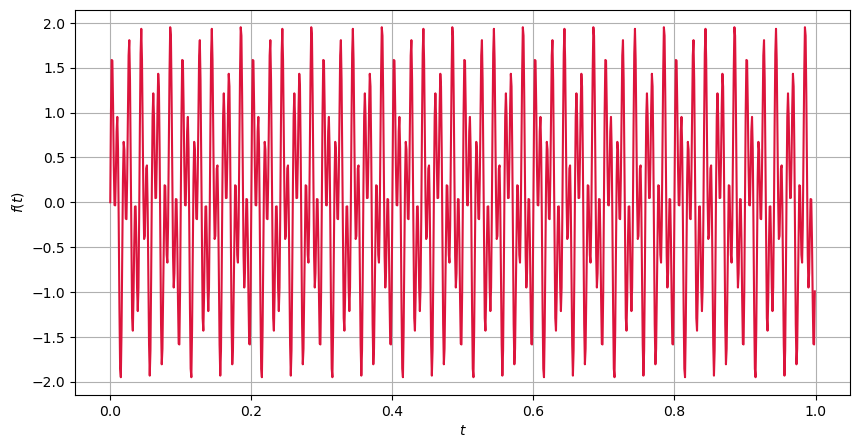

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Reading the data
t, signal = np.loadtxt('clean_synth_signal.txt', unpack=True)

plt.figure(figsize=(10,5))
plt.plot(t, signal, color='crimson')
plt.title('')
plt.xlabel(r'$t$')
plt.ylabel(r'$f(t)$')
plt.grid()
plt.show()

We calculate the Fourier Transform of this function using `numpy.fft.fft`, which gives the coefficients $c_k = N \gamma_k$, where $N$ is the number of points considered in the transformation.

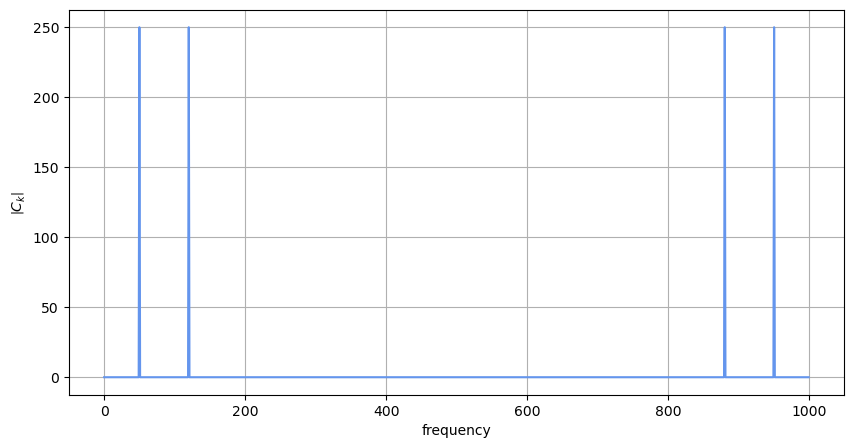

In [8]:
## Fast Fourier Transform
n = len(t)
c = np.fft.fft(signal) #computes the fft
dt = t[1] - t[0]
psd = c*np.conj(c)/n
freq = (1/(dt*n)) * np.arange(n) #frequency array

plt.figure(figsize=(10,5))
plt.plot(freq, abs(psd), color='cornflowerblue')
plt.title('')
plt.xlabel(r'frequency')
plt.ylabel(r'$\left| C_k \right|$')
plt.grid()
plt.show()

It is possible to identify four frequencies in this transformation, however, the information here is duplicated due to the real character of the function. Thus only the first two frequencies are trelevant for the representation of $f(t)$. The values of thes frequencies are

In [14]:
## Filter out the relevant frequencies
threshold = 100
psd_idxs = psd > threshold # array of 0s and 1s

indices = np.where(psd_idxs)[0]
print('Frequencies in the transformation:')
for i in indices:
    print(freq[i])

Frequencies in the transformation:
50.0
120.0
880.0
950.0


The function  `numpy.fft.ifft`, gives the inverse of the Fourier transformation, i.e. recompose the original function using the superposition of the relevant frequencies.

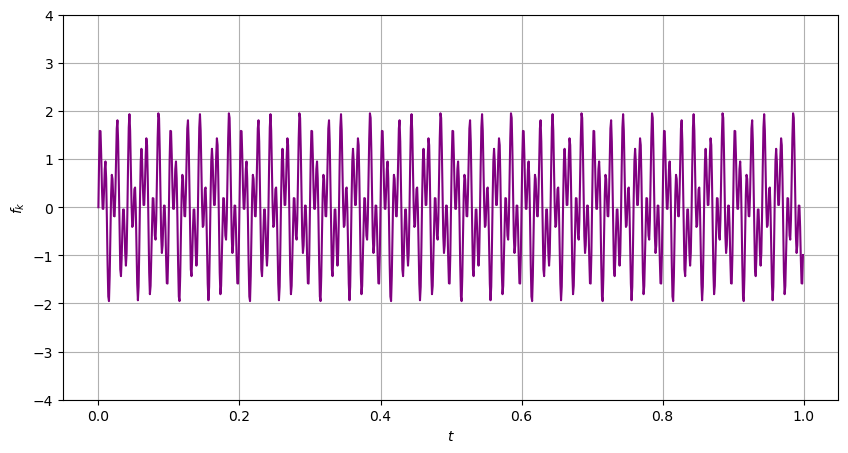

In [16]:

psd_clean = psd * psd_idxs # zero out all the unnecessary powers
c_clean = psd_idxs * c # used to retrieve the signal

recomposed_f = np.fft.ifft(c_clean) #inverse fourier transform

plt.figure(figsize=(10,5))
plt.plot(t, np.real(recomposed_f), color='purple')
plt.ylim(-4,4)
plt.title('')
plt.xlabel(r'$t$')
plt.ylabel(r'$ f_k $')
plt.grid()
plt.show()

---
---

In [ ]:
## Create the synthetic signal
dt = 0.001
t = np.arange(0, 1, dt)
signal = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t) # composite signal

data = np.column_stack((t,signal))
np.savetxt('clean_synth_signal.txt',data)

---
---

### Example 02

The file `signal.txt` contains the data of a signal for which we will calculate its Fourier transform.

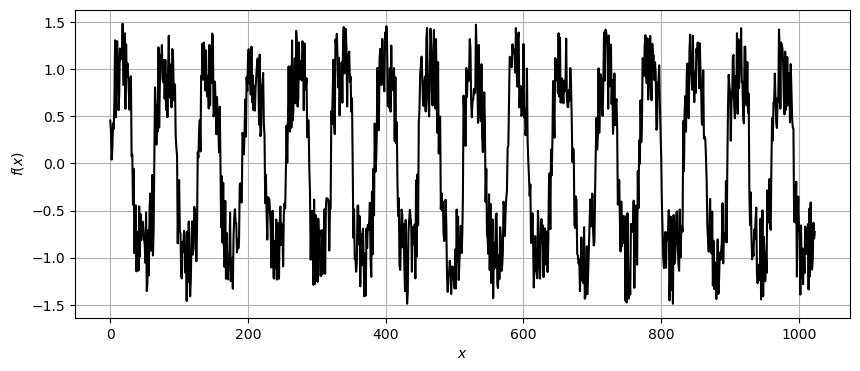

In [17]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Reading the data
f_data = np.loadtxt( 'signal.txt')
x_data = np.arange(len(f_data))
plt.figure(figsize=(10,4))
plt.plot(x_data, f_data, color='black')
plt.title('')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.grid()
plt.show()

The total number of datapoints in the file is

In [18]:
n = len(f_data)
n

1024

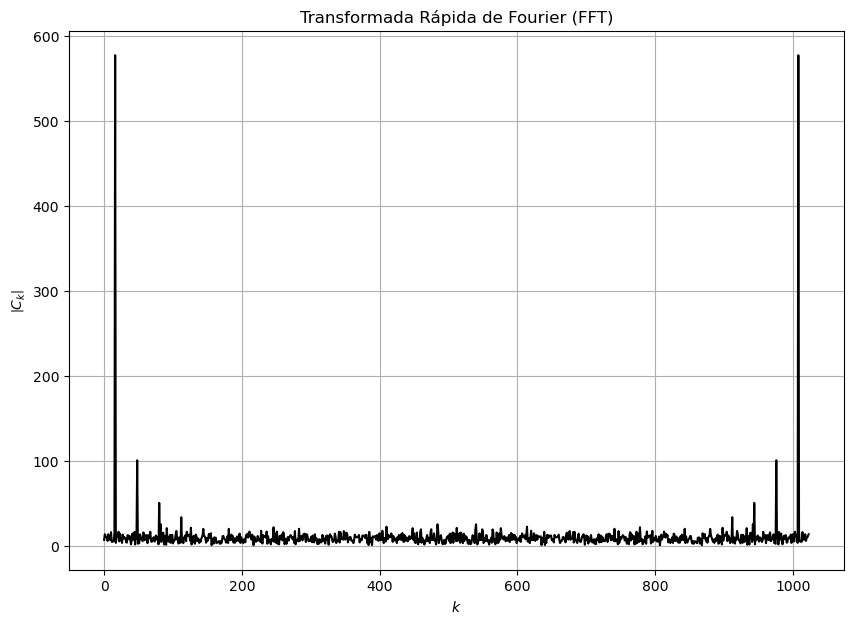

In [20]:
from scipy.fft import fft

C = fft(f_data)
plt.figure(figsize=(10,7))
plt.plot(range(len(C)), abs(C), color='black')
plt.title('')
plt.xlabel(r'$k$')
plt.ylabel(r'$\left| C_k \right|$')
plt.title(r'Transformada Rápida de Fourier (FFT)')
plt.grid()
plt.show()